In [140]:
import os
import time
import re

import seaborn as sns
import matplotlib.pyplot as plt

from scipy import sparse

import scanpy as sc
import anndata as ad

import pandas as pd
import numpy as np

import sys
sclembas_path = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas_path))
from scLEMBAS import preprocess as pp
from scLEMBAS import io

In [2]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

In [3]:
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'
seed = 888

Load in the data:

In [99]:
adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_filtered_counts.h5ad'))


Normalize and get HVGs:

In [101]:
# %%time
sc.pp.normalize_total(adata, target_sum = 1e6)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=5000, batch_key=None, flavor = 'seurat')


CPU times: user 56.1 s, sys: 1.08 s, total: 57.2 s
Wall time: 57.2 s


Get the TF activity:

In [145]:
# %%time

n_batches = 20
batch_size = int(np.round(adata.shape[0]/n_batches))
kwargs = {'args' : {'wsum' : {'times': int(1), # don't use the p-vals
                              'batch_size': batch_size},
                       'ulm' : {'batch_size': batch_size}, 
                        'mlm': {'batch_size': batch_size}
                       }, 
         'methods': ['wsum', 'ulm', 'mlm'], 
         'cns_metds': ['wsum_estimate', 'ulm_estimate', 'mlm_estimate']}
# default is wsum_norm, which introduces inf values that result in nan when z-scoring..
# also intuitively doesnt make sense to z-score an already normalized value
# particularly when the other z-scores or on the non-normalized values



adata = pp.get_tf_activity(adata = adata, 
                           organism = 'human', 
                           grn = 'collectri', 
                           verbose = True,
                           consensus = True, 
                           hvg = True,
                           static = True,
                           use_raw = False, 
                           min_n = 5, 
                           filter_pvals = False, pval_thresh = 0.05, 
                           **kwargs)

# normalization, hvgs, and TF scores
adata.write_h5ad(os.path.join(data_path, 'processed', author + '_expr_normalized_scored.h5ad'))

In [126]:
tf_adata = pp.tf_to_adata(adata, estimate_key = 'consensus_estimate')
io.write_tfad(tf_adata, file_name = os.path.join(data_path, 'interim', author + 'consensus_tf_activity.h5ad'))

''

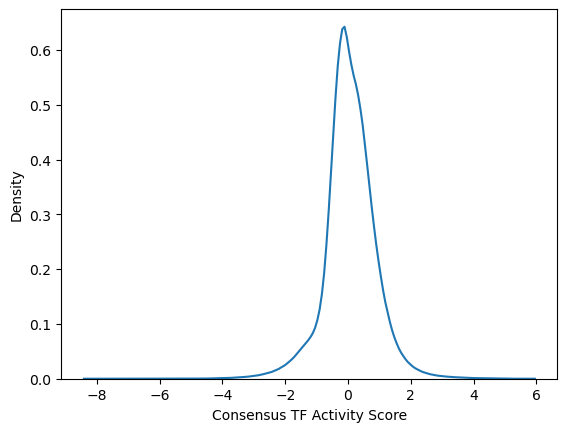

In [149]:
n_sample = int(1e4)
np.random.seed(seed)
obs_sub = np.random.choice(tf_adata.obs_names, 
                 size = n_sample, 
                 replace = False)

viz_dist = tf_adata[obs_sub, :].to_df().values.flatten()


fig, ax = plt.subplots()
sns.kdeplot(viz_dist, ax = ax)
ax.set_xlabel('Consensus TF Activity Score')
;
